# Lipidomics — the *lipidr* workflow in omicverse

Lipidomics has enough structure to deserve a dedicated analysis path. Every
lipid follows the **LIPID MAPS shorthand** (`PE 34:1`, `TAG 54:3`,
`Cer d18:1/24:0`), targeted assays report several **transitions** per lipid,
and the biology is organised by **class**, **chain length** and
**unsaturation** — none of which a generic metabolomics pipeline exploits.

`omicverse` integrates the Bioconductor **[lipidr](https://bioconductor.org/packages/lipidr)**
workflow through the pure-Python [`pylipidr`](https://github.com/omicverse/py-lipidr)
backend. Every step is a registered `ov.metabol` function and every object is
a plain `AnnData`, so lipidomics drops straight into the rest of omicverse.

**Pipeline.** `read_skyline` → `add_sample_annotation` → `summarize_transitions`
→ `annotate_lipids` → `normalize_pqn` → `de_lipids` → `lsea` / `lipid_mva`.

> Install the backend with `pip install omicverse[lipidomics]`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import omicverse as ov

ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.1rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1 — Download a raw Skyline dataset

We use `lipidr`'s own targeted-lipidomics example — a **mouse diet study**
(Salek/Mohamed): liver lipids measured by LC-MS/MS, exported from Skyline.
Two MIT-licensed files live on GitHub, so nothing is bundled locally:

- `A1_data.csv` — the long Skyline transition table (one row per transition)
- `clin.csv` — sample metadata: `group`, `Diet` (Normal / HighFat), `BileAcid`

`ov.datasets.download_data` caches each file under `./metabol_data`.

In [2]:
base = 'https://raw.githubusercontent.com/ahmohamed/lipidr/master/inst/extdata'
skyline_path = ov.datasets.download_data(
    url=f'{base}/A1_data.csv', file_path='A1_data.csv', dir='./metabol_data',
)
clin_path = ov.datasets.download_data(
    url=f'{base}/clin.csv', file_path='clin.csv', dir='./metabol_data',
)

🔍 Downloading data to ./metabol_data/A1_data.csv
⚠️ File ./metabol_data/A1_data.csv already exists
🔍 Downloading data to ./metabol_data/clin.csv
⚠️ File ./metabol_data/clin.csv already exists


## 2 — Read the Skyline export

`ov.metabol.read_skyline` pivots the long transition table into an
`AnnData` (**samples × transitions**). `ov.metabol.add_sample_annotation`
joins the clinical table onto `adata.obs` by sample id.

In [3]:
adata = ov.metabol.read_skyline(skyline_path)
adata = ov.metabol.add_sample_annotation(adata, clin_path)
print(adata)
print('groups:', adata.obs['group'].value_counts().to_dict())

AnnData object with n_obs × n_vars = 58 × 102
    obs: 'group', 'Diet', 'BileAcid'
    var: 'Molecule', 'TransitionId', 'Class_skyline', 'Class', 'Category', 'total_cl', 'total_cs', 'chains', 'not_parsed', 'istd'
    uns: 'lipidr_default_measure', 'lipidr_state'
groups: {'QC': 12, 'NormalDiet_water': 11, 'NormalDiet_DCA': 11, 'HighFat_water': 11, 'HighFat_DCA': 11, 'blank': 2}


## 3 — Summarize transitions

A targeted assay records **several transitions per lipid** (different
product ions). `summarize_transitions` collapses them to one value per
lipid — `method='max'` keeps the most intense transition, the lipidr
default and the most robust choice for quantification.

In [4]:
adata = ov.metabol.summarize_transitions(adata, method='max')
print('after summarization:', adata.shape, '(samples × lipids)')

after summarization: (58, 101) (samples × lipids)


## 4 — Annotate lipids with Goslin

`ov.metabol.annotate_lipids` parses every lipid name with the **Goslin**
reference engine (`pygoslin`) and writes `lipid_class`, `lipid_category`,
`total_carbons`, `total_db` and `lipid_backbone` into `adata.var`. Goslin
understands the LIPID MAPS shorthand *and* the common vendor dialects, so
ether lipids (`PE-O`, `PE-P`) and sphingolipids parse correctly.

In [5]:
adata = ov.metabol.annotate_lipids(adata)
print('lipid classes:')
print(adata.var['lipid_class'].value_counts())

lipid classes:
lipid_class
PE      25
PI      22
PE-O    18
PE-P    18
PG      11
PI-P     1
Name: count, dtype: int64


## 5 — Normalize with PQN

`normalize_pqn` applies **Probabilistic Quotient Normalization**: each
sample is scaled by the median quotient of its lipids against a reference
profile — robust to a few highly variable species. `exclude='blank'`
drops the solvent blanks before building the reference, and `log=True`
returns a log2 matrix ready for linear modelling.

In [6]:
norm = ov.metabol.normalize_pqn(adata, measure='Area', exclude='blank', log=True)
print('normalized:', norm.shape, '(blanks dropped)')
print(f'log2 intensity range: {norm.X.min():.1f} .. {norm.X.max():.1f}')

normalized: (56, 101) (blanks dropped)
log2 intensity range: 5.7 .. 23.7


## 6 — Differential analysis

`ov.metabol.de_lipids` runs **limma moderated-t** — the small-sample
workhorse that borrows variance across lipids, far more powerful than a
per-lipid t-test at *n* ≈ 11/group. We contrast a high-fat vs normal diet
(both on water). The result table carries lipid-class annotations, which
`lsea` needs downstream.

In [7]:
de = ov.metabol.de_lipids(
    norm, 'HighFat_water - NormalDiet_water', group_col='group',
)
n_sig = int((de['adj.P.Val'] < 0.05).sum())
print(f'{n_sig} / {len(de)} lipids differential at adj.P < 0.05')
de.sort_values('P.Value').head()[
    ['Molecule', 'Class', 'logFC', 'P.Value', 'adj.P.Val']]

79 / 101 lipids differential at adj.P < 0.05


,Molecule,Class,logFC,P.Value,adj.P.Val
0,PE(P-38:3),PE,1.699273,8.614843e-16,8.700992e-14
1,PE(O-38:4),PE,1.765957,3.418962e-15,1.726576e-13
2,PI 34:2,PI,-1.252535,1.469847e-14,4.948485e-13
3,PG 18:2/18:0,PG,1.855818,4.051081e-14,1.022898e-12
4,PG 18:2/18:1,PG,2.271831,6.715486e-14,1.356528e-12


A diet swap remodels the liver lipidome wholesale, so most lipids move —
exactly the regime moderated-t was built for. The volcano below uses
`ov.metabol.volcano`; we rename the lipidr-style columns to the generic
`log2fc` / `pvalue` / `padj` that omicverse plotting expects.

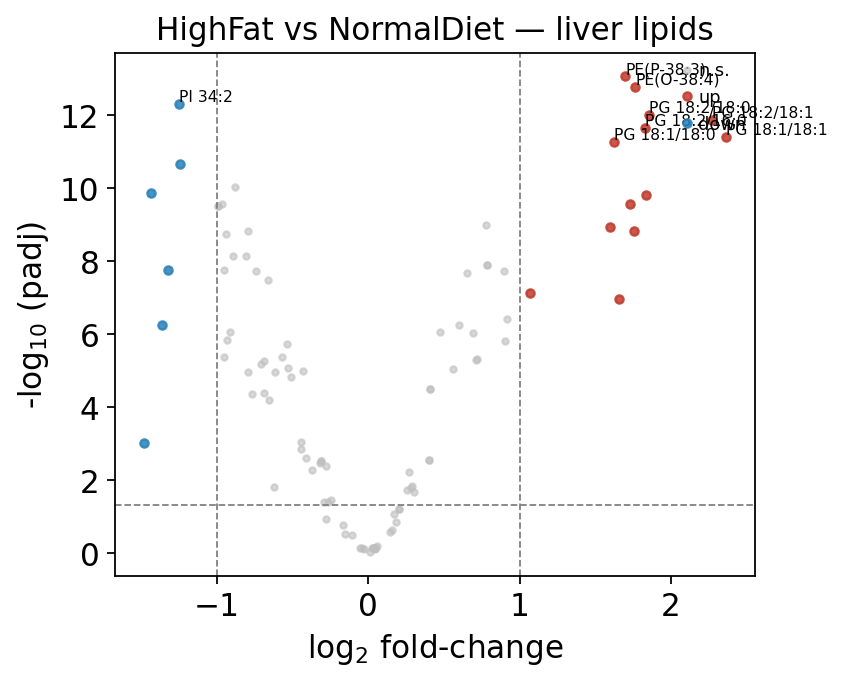

In [8]:
deg = de.rename(columns={
    'logFC': 'log2fc', 'P.Value': 'pvalue', 'adj.P.Val': 'padj',
}).set_index('Molecule')
fig, ax = ov.metabol.volcano(deg, padj_thresh=0.05, log2fc_thresh=1.0,
                             label_top_n=8)
ax.set_title('HighFat vs NormalDiet — liver lipids')
plt.tight_layout(); plt.show()

## 7 — Lipid Set Enrichment Analysis

`ov.metabol.lsea` runs a **preranked GSEA** over lipid sets built
automatically from class, total chain length and total unsaturation —
it answers *"which lipid groups move coherently?"* rather than testing
species one by one. Sets are ranked by enrichment score (`ES`).

In [9]:
enr = ov.metabol.lsea(de, rank_by='logFC', nperm=2000)
enr.sort_values('pval').head(10)[
    ['set', 'ES', 'NES', 'pval', 'padj', 'size']]

,set,ES,NES,pval,padj,size
0,Class_PG,0.966667,2.381726,0.000846,0.015228,11
1,Class_PI,-0.619609,-2.047305,0.003012,0.027108,23
2,total_cs_4,0.705023,1.714467,0.012584,0.075503,10
3,total_cl_34,-0.489244,-1.525266,0.040059,0.180267,19
4,total_cl_36,0.476344,1.450170,0.050439,0.181579,29
5,total_cl_32,-0.593723,-1.429414,0.093516,0.246663,8
6,total_cl_18,0.868687,1.326131,0.108213,0.246663,2
7,Class_SPH,0.868687,1.325317,0.109628,0.246663,2
8,total_cs_2,-0.358807,-1.123383,0.273115,0.546230,18
9,total_cs_3,-0.359576,-1.049363,0.377868,0.672516,14


## 8 — Acyl-chain map

The signature lipidomics figure: a **carbon × double-bond grid** per
class, each cell coloured by the differential statistic. It exposes
trends a volcano hides — e.g. whether a class shifts toward longer or
more unsaturated chains. `ov.metabol.acyl_chain_map` parses every lipid
name and lays out one heatmap panel per class.

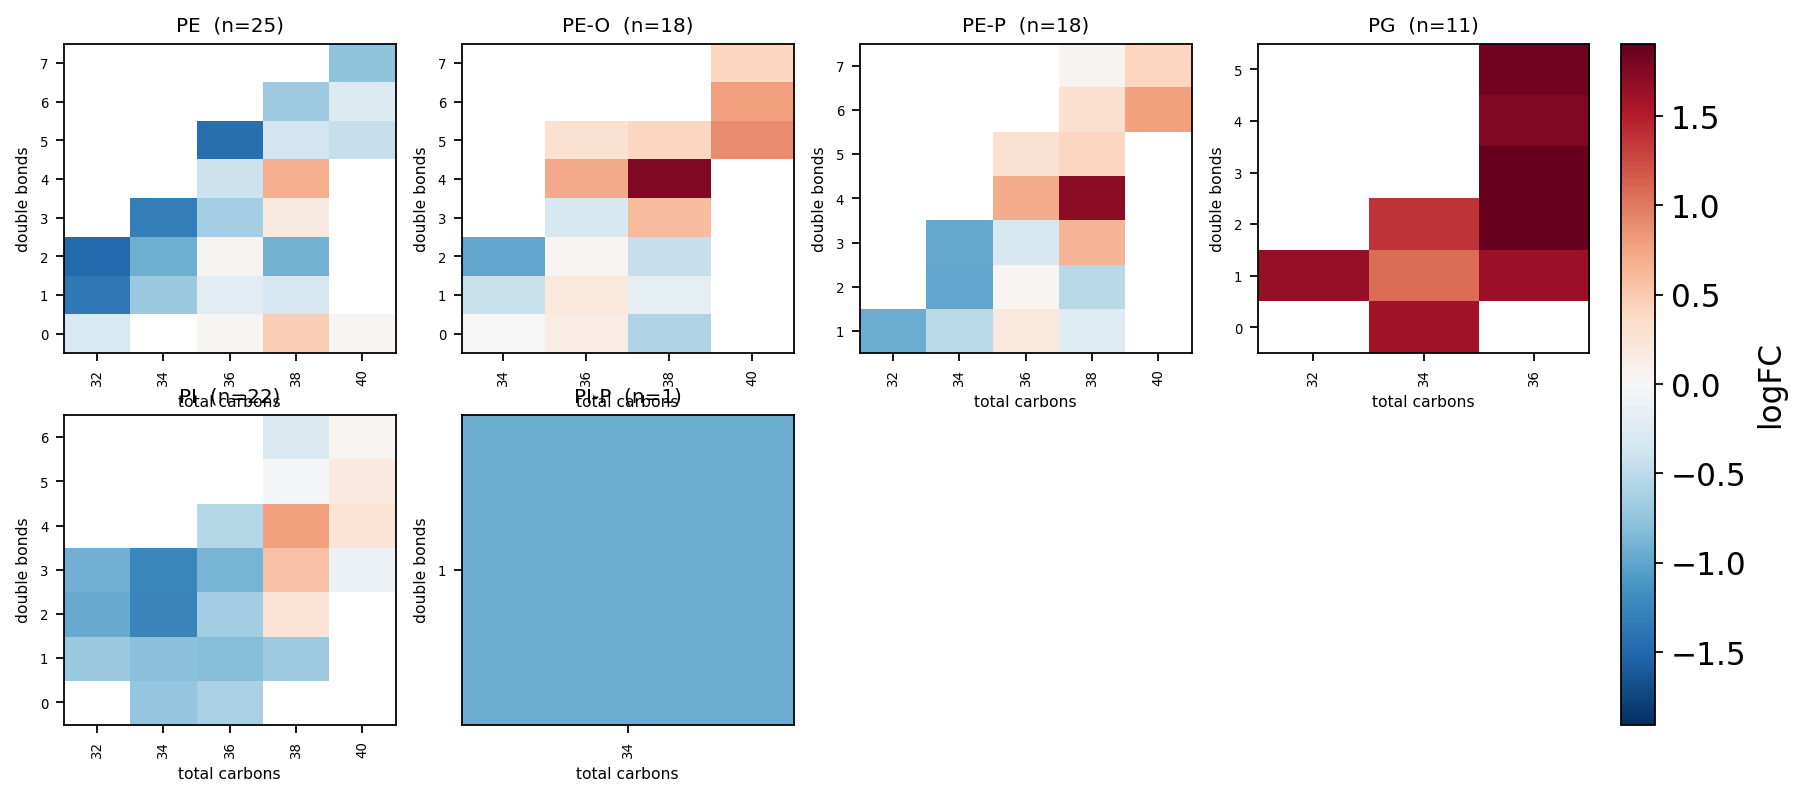

In [10]:
fig = ov.metabol.acyl_chain_map(
    de.set_index('Molecule'), value_col='logFC', n_cols=4,
)
plt.show()

## 9 — Multivariate analysis

`ov.metabol.lipid_mva` provides **PCA / PCoA / OPLS-DA** on the lipid
matrix. PCA on the biological samples (QC dropped) shows how strongly the
two diets separate. The score plot below colours samples by `Diet`.

In [11]:
bio = norm[norm.obs['group'] != 'QC'].copy()
mva = ov.metabol.lipid_mva(bio, method='PCA', group_col='Diet')
print('explained variance:', np.round(mva.explained_variance[:3], 3))

explained variance: [0.446 0.146 0.102]


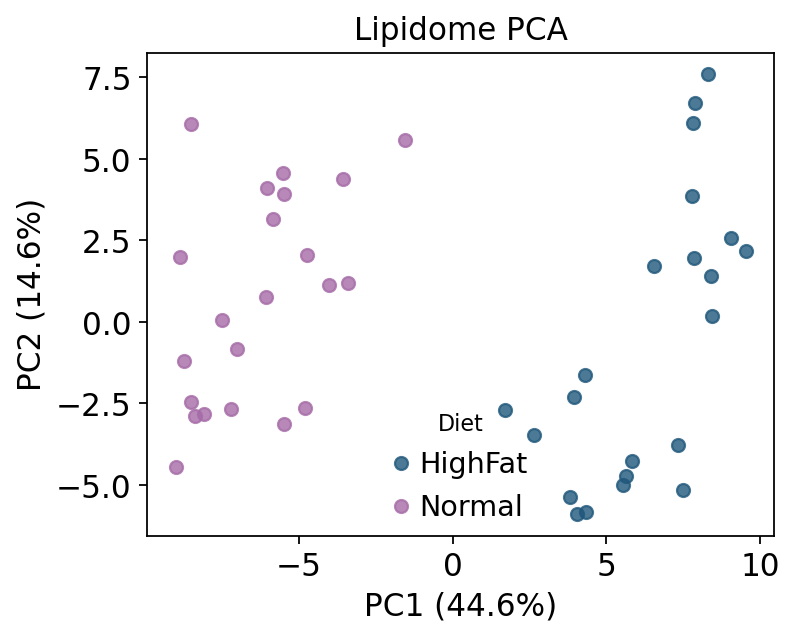

In [12]:
scores = mva.scores
diet = bio.obs['Diet'].reindex(scores.index).astype(str)
fig, ax = plt.subplots(figsize=(5, 4.2))
for g in sorted(diet.unique()):
    m = (diet == g).to_numpy()
    ax.scatter(scores.iloc[m, 0], scores.iloc[m, 1], label=g, s=34, alpha=0.8)
ax.set_xlabel(f'PC1 ({mva.explained_variance[0] * 100:.1f}%)')
ax.set_ylabel(f'PC2 ({mva.explained_variance[1] * 100:.1f}%)')
ax.legend(title='Diet', frameon=False); ax.set_title('Lipidome PCA')
plt.tight_layout(); plt.show()

## 10 — Class-level composition

For a quick whole-lipidome overview, `ov.metabol.aggregate_by_class`
collapses the species matrix to per-class totals. A stacked bar of the
mean composition per group is the first plot most lipidomics papers show.

In [13]:
no_blank = adata[adata.obs['group'] != 'blank']
cls = ov.metabol.aggregate_by_class(no_blank, agg='sum')
cls.obs = no_blank.obs
print('class-level matrix:', cls.shape)
cls.var

class-level matrix: (56, 6)


,n_species
PE,25
PE-O,18
PE-P,18
PG,11
PI,22
PI-P,1


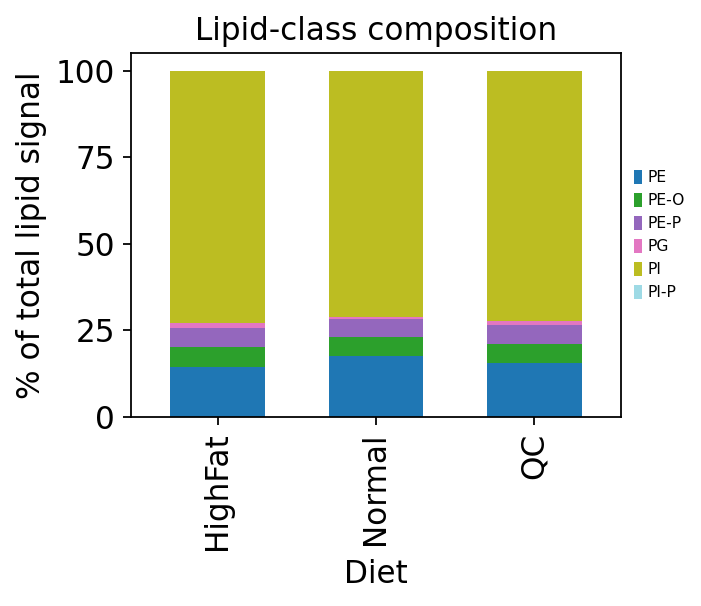

In [14]:
comp = pd.DataFrame(cls.X, index=cls.obs_names, columns=cls.var_names)
comp['Diet'] = cls.obs['Diet'].values
pct = comp.groupby('Diet').mean().T
pct = pct.div(pct.sum(axis=0), axis=1) * 100
fig, ax = plt.subplots(figsize=(4.6, 4))
pct.T.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.6)
ax.set_ylabel('% of total lipid signal'); ax.set_xlabel('Diet')
ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=False,
          fontsize=7)
ax.set_title('Lipid-class composition')
plt.tight_layout(); plt.show()

## Summary

A complete lipidomics analysis, all `AnnData`-native:

| Step | `ov.metabol` function | What it does |
|---|---|---|
| Import | `read_skyline` | Skyline export → AnnData |
| Metadata | `add_sample_annotation` | join clinical table |
| Collapse | `summarize_transitions` | transitions → one value per lipid |
| Annotate | `annotate_lipids` | Goslin class / category / chains |
| Normalize | `normalize_pqn` · `normalize_istd` | PQN / internal-standard |
| Differential | `de_lipids` | limma moderated-t |
| Enrichment | `lsea` · `lion_enrichment` | lipid-set GSEA · LION ORA |
| Multivariate | `lipid_mva` | PCA / PCoA / OPLS-DA |
| Visualize | `volcano` · `acyl_chain_map` · `aggregate_by_class` | |

The analysis engine is the standalone, R-parity-tested `pylipidr` port of
Bioconductor *lipidr*; `ov.metabol` exposes it as registered functions so
lipidomics composes with every other omicverse module.